State-Space System:
<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[ 0.   1. ]
     [-2.  -0.5]]

B = [[0.]
     [1.]]

C = [[1. 0.]]

D = [[0.]]
System Poles:
[-0.25+1.39194109j -0.25-1.39194109j]

Controllable: True (rank = 2)
Observable:   True (rank = 2)


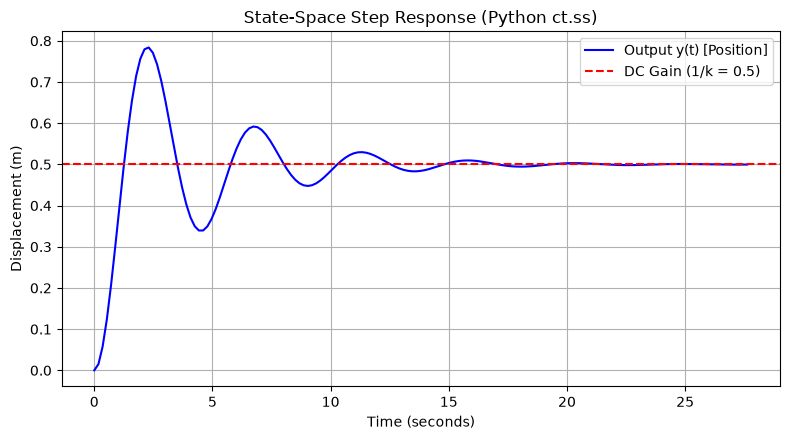

In [1]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# 1. System Parameters (Mass-Spring-Damper)
m = 1.0   # Mass (kg)
b = 0.5   # Damping coefficient (N*s/m)
k = 2.0   # Spring stiffness (N/m)

# 2. State-Space Matrices:
# State vector: x = [position; velocity]
# Input: u = force
# Output: y = position
A = np.array([[0.0,      1.0],
              [-k / m, -b / m]])

B = np.array([[0.0],
              [1.0 / m]])

C = np.array([[1.0, 0.0]])

D = np.array([[0.0]])

# 3. Construct Continuous State-Space Model
sys = ct.ss(A, B, C, D)
print("State-Space System:")
print(sys)

# 4. System Characteristics
# System poles (eigenvalues of A)
poles = ct.poles(sys)
print(f"System Poles:\n{poles}\n")

# Controllability & Observability
Co = ct.ctrb(A, B)
Ob = ct.obsv(A, C)

is_controllable = np.linalg.matrix_rank(Co) == A.shape[0]
is_observable = np.linalg.matrix_rank(Ob) == A.shape[0]

print(f"Controllable: {is_controllable} (rank = {np.linalg.matrix_rank(Co)})")
print(f"Observable:   {is_observable} (rank = {np.linalg.matrix_rank(Ob)})")

# 5. Simulate Step Response
time_vector, response = ct.step_response(sys)

# 6. Plotting
plt.figure(figsize=(8, 4.5))
plt.plot(time_vector, response, label="Output y(t) [Position]", color="blue")
plt.axhline(1.0 / k, color="red", linestyle="--", label=f"DC Gain (1/k = {1.0 / k})")
plt.title("State-Space Step Response (Python ct.ss)")
plt.xlabel("Time (seconds)")
plt.ylabel("Displacement (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()